# Wrong-K experiment — protocol step 5

Sampling slots are aligned without the target, using iterative consensus. NMSE uses a separate cardinality-aware oracle assignment so missing and extra sources are penalized.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:

RESULT_DIR = Path('results/run_20260903_170728_epoch_23')
if not RESULT_DIR.exists(): RESULT_DIR = Path('experiments') / RESULT_DIR
results = pd.read_csv(RESULT_DIR / 'wrong_k_iterative_consensus.csv')
results.consensus_converged = results.consensus_converged.astype(bool)
print(f"{results.mixture_id.nunique():,} mixtures; convergence: {results.consensus_converged.mean():.2%}")
results.head()

1,000 mixtures; convergence: 100.00%


,mixture_id,true_K,given_K,delta_K,u_pred,u_true,nmse,consensus_converged,consensus_iterations,medoid_sampling
0,0,6,5,-1,0.129652,0.119639,0.043006,True,2,5
1,1,3,2,-1,0.105358,0.099785,0.065830,True,2,8
2,2,5,4,-1,0.316004,0.283186,0.190538,True,2,4
3,3,3,2,-1,0.139742,0.120917,0.117109,True,2,1
4,4,8,7,-1,0.226914,0.200349,0.108615,True,2,6


In [3]:
INK, GRID = '#253047', '#DDE3EA'
COLORS = {-1:'#88CCEE', 0:'#44AA99', 1:'#CC6677'}
LABELS = {-1:'K − 1', 0:'Correct K', 1:'K + 1'}
STYLE = {'figure.facecolor':'white', 'axes.facecolor':'white', 'axes.edgecolor':'#CBD2DC',
         'axes.labelcolor':INK, 'font.size':11, 'axes.titlesize':14, 'axes.labelsize':12}

def bootstrap_mean_ci(frame, column, repetitions=2000, seed=42):
    pivot = frame.pivot(index='mixture_id', columns='delta_K', values=column).dropna()
    values = pivot.to_numpy(); rng = np.random.default_rng(seed)
    means = np.empty((repetitions, values.shape[1]))
    for index in range(repetitions):
        means[index] = values[rng.integers(0, len(values), len(values))].mean(axis=0)
    return pivot.columns.to_numpy(), values.mean(axis=0), np.quantile(means, [0.025, 0.975], axis=0)

def clean(ax):
    ax.grid(axis='y', color=GRID, linewidth=0.8); ax.tick_params(axis='both', length=0)
    ax.spines[['top', 'right']].set_visible(False)

## Aggregate paired comparison over the same 1000 mixtures

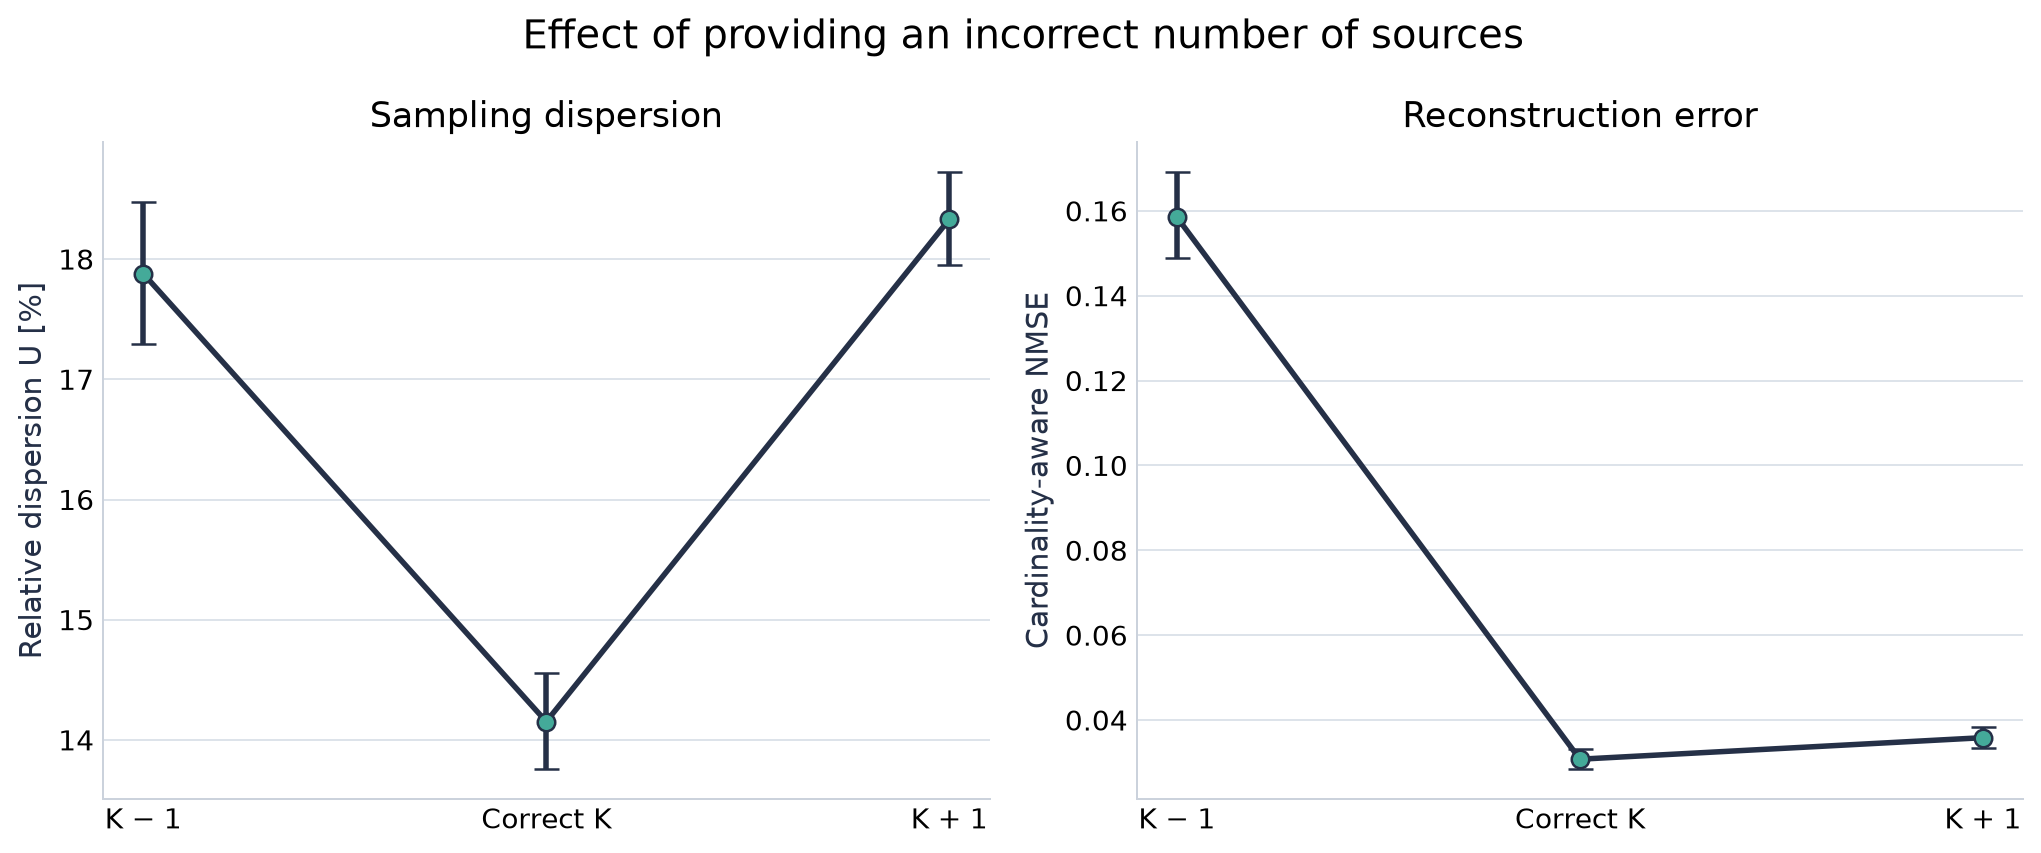

In [4]:
U_COLUMN = 'u_pred'  # Change to 'u_true' to inspect the target-normalized variant
with plt.rc_context(STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), dpi=180)
    for ax, column, ylabel, scale in [
        (axes[0], U_COLUMN, 'Relative dispersion U [%]', 100),
        (axes[1], 'nmse', 'Cardinality-aware NMSE', 1),
    ]:
        deltas, means, ci = bootstrap_mean_ci(results, column)
        y, low, high = scale * means, scale * ci[0], scale * ci[1]
        ax.errorbar(deltas, y, yerr=[y-low, high-y], color=INK, linewidth=2.2,
                    marker='o', markersize=7, markerfacecolor='#44AA99', capsize=5)
        ax.set_xticks(deltas, [LABELS[d] for d in deltas]); ax.set_ylabel(ylabel); clean(ax)
    axes[0].set_title('Sampling dispersion'); axes[1].set_title('Reconstruction error')
    fig.suptitle('Effect of providing an incorrect number of sources', fontsize=16)
    fig.tight_layout(); plt.show()

## Results separated by true K

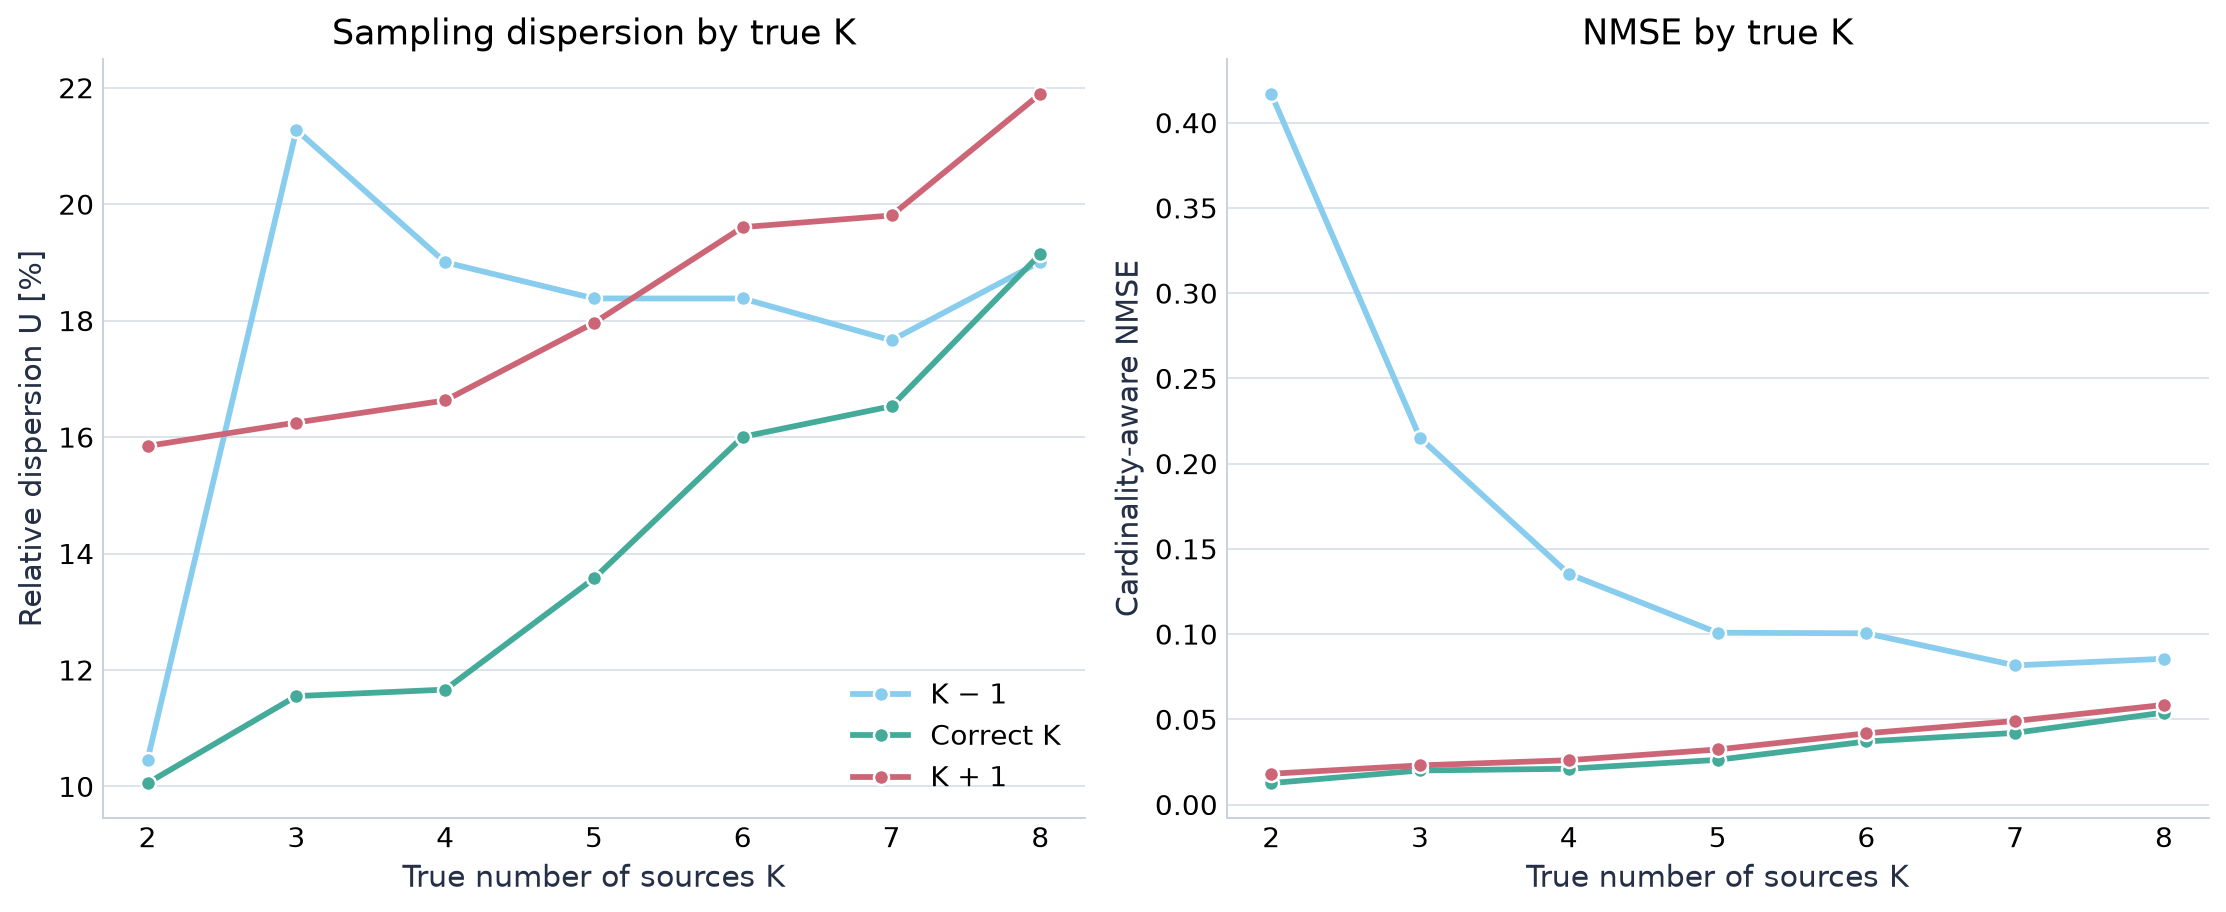

In [5]:
with plt.rc_context(STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), dpi=180)
    for delta in (-1, 0, 1):
        grouped = results[results.delta_K == delta].groupby('true_K')[[U_COLUMN, 'nmse']].mean()
        axes[0].plot(grouped.index, 100*grouped[U_COLUMN], color=COLORS[delta], marker='o',
                     linewidth=2.3, markeredgecolor='white', label=LABELS[delta])
        axes[1].plot(grouped.index, grouped.nmse, color=COLORS[delta], marker='o',
                     linewidth=2.3, markeredgecolor='white', label=LABELS[delta])
    axes[0].set_ylabel('Relative dispersion U [%]'); axes[1].set_ylabel('Cardinality-aware NMSE')
    for ax in axes:
        ax.set_xlabel('True number of sources K'); ax.set_xticks(sorted(results.true_K.unique())); clean(ax)
    axes[0].set_title('Sampling dispersion by true K'); axes[1].set_title('NMSE by true K')
    axes[0].legend(frameon=False); fig.tight_layout(); plt.show()

## Consensus diagnostics

In [6]:
results.groupby('delta_K').agg(
    mixtures=('mixture_id', 'size'),
    convergence_rate=('consensus_converged', 'mean'),
    mean_iterations=('consensus_iterations', 'mean'),
)

,mixtures,convergence_rate,mean_iterations
delta_K,,,
-1,1000,1.0,2.015
0,1000,1.0,2.021
1,1000,1.0,2.062
